# 🧠 Resumo — Redes Neurais Rasas (Shallow Neural Networks)

## 1. Conceito

Uma **rede neural rasa** (Shallow Neural Network) possui **apenas uma camada oculta** entre a entrada e a saída.

Ela aprende uma função de mapeamento:

$$
\hat{y} = f(X; W, b)
$$

onde:
- $X$: entrada  
- $W$: pesos  
- $b$: vieses  
- $f$: função composta das ativações

---

## 2. Estrutura

**Arquitetura típica:**

$$
\text{Input} \rightarrow [\text{Hidden Layer}] \rightarrow \text{Output}
$$

Cada neurônio da camada oculta calcula:

$$
z^{[1]} = W^{[1]} x + b^{[1]}
$$

$$
a^{[1]} = g(z^{[1]})
$$

onde $g(\cdot)$ é uma **função de ativação** (ex: sigmoid, tanh, ReLU).

Na saída:

$$
\hat{y} = g^{[2]}(W^{[2]} a^{[1]} + b^{[2]})
$$

---

## 3. Funções de Ativação

| Nome | Fórmula | Intervalo |
|------|----------|------------|
| **Sigmoid** | $\sigma(z) = \frac{1}{1 + e^{-z}}$ | (0, 1) |
| **tanh** | $\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$ | (-1, 1) |
| **ReLU** | $\text{ReLU}(z) = \max(0, z)$ | [0, ∞) |
| **Leaky ReLU** | $\text{LeakyReLU}(z) = \max(0.01z, z)$ | (-∞, ∞) |

---

## 4. Forward Propagation

Fluxo de cálculo da previsão:

1. Calcular a entrada da camada oculta  
   $$ z^{[1]} = W^{[1]} x + b^{[1]} $$
2. Aplicar a ativação  
   $$ a^{[1]} = g(z^{[1]}) $$
3. Calcular a saída  
   $$ z^{[2]} = W^{[2]} a^{[1]} + b^{[2]} $$
4. Ativar a saída  
   $$ \hat{y} = g^{[2]}(z^{[2]}) $$

---

## 5. Função de Custo

Para classificação binária (ex: sigmoid na saída):

$$
J(W, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$

---

## 6. Backpropagation

Usa o **gradiente descendente** para atualizar pesos e vieses.

### Derivadas:
1. Erro na saída:
   $$
   dZ^{[2]} = \hat{y} - y
   $$
2. Gradiente da camada de saída:
   $$
   dW^{[2]} = \frac{1}{m} dZ^{[2]} (A^{[1]})^T
   $$
   $$
   db^{[2]} = \frac{1}{m} \sum dZ^{[2]}
   $$
3. Erro propagado para camada oculta:
   $$
   dZ^{[1]} = (W^{[2]})^T dZ^{[2]} \odot g'(Z^{[1]})
   $$
4. Gradientes da camada oculta:
   $$
   dW^{[1]} = \frac{1}{m} dZ^{[1]} X^T
   $$
   $$
   db^{[1]} = \frac{1}{m} \sum dZ^{[1]}
   $$

---

## 7. Atualização dos Pesos

Usando **Gradiente Descendente**:

$$
W^{[l]} := W^{[l]} - \alpha \, dW^{[l]}
$$

$$
b^{[l]} := b^{[l]} - \alpha \, db^{[l]}
$$

onde $\alpha$ é a taxa de aprendizado (learning rate).

---

## 8. Interpretação Geométrica

A rede aprende **hiperplanos** que separam os dados no espaço de entrada.  
Cada neurônio aprende uma fronteira linear, e as ativações não lineares permitem que a rede combine várias fronteiras — formando regiões complexas de decisão.

---

## 9. Limitações

- Captura **relações simples** (pouca profundidade → pouca expressividade)  
- Pode **underfittar** dados complexos  
- Escala mal para imagens, texto e áudio  
- Serve bem como **introdução teórica e base** para redes profundas (Deep Learning)

---

> **Resumo prático:**  
> Uma *shallow neural network* é o primeiro passo no aprendizado de representações não lineares.  
> Ela combina **regressão linear + ativação + retropropagação**, e já é suficiente para entender os blocos fundamentais de uma rede profunda.


# 🧠 Representação de uma Rede Neural com Uma Camada Oculta

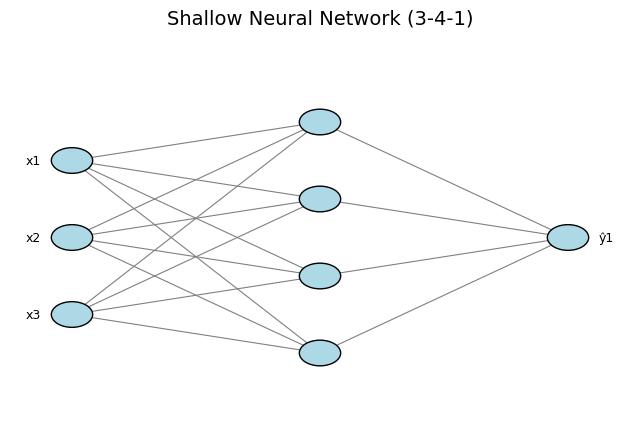

In [2]:
# ===============================================
# Visualização de uma Shallow Neural Network
# ===============================================

import matplotlib.pyplot as plt
import numpy as np

def draw_neural_net(ax, left, right, bottom, top, layer_sizes):
    """
    Desenha uma rede neural rasa.
    Parâmetros:
    - ax: eixo matplotlib
    - left, right, bottom, top: coordenadas do gráfico
    - layer_sizes: lista com número de neurônios em cada camada (ex: [3, 4, 1])
    """
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(n_layers - 1)

    # Desenhar os neurônios camada por camada
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing*(layer_size - 1)/2. + (top + bottom)/2.
        for m in range(layer_size):
            # Coordenadas de cada neurônio
            x = n*h_spacing + left
            y = layer_top - m*v_spacing
            circle = plt.Circle((x, y), v_spacing/6., color='lightblue', ec='k', zorder=4)
            ax.add_artist(circle)
            # Texto com índice
            if n == 0:
                ax.text(x - 0.05, y, f"x{m+1}", ha='right', va='center', fontsize=9)
            elif n == n_layers - 1:
                ax.text(x + 0.05, y, f"ŷ{m+1}", ha='left', va='center', fontsize=9)

    # Desenhar as conexões entre camadas
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for m in range(layer_size_a):
            for o in range(layer_size_b):
                line = plt.Line2D([n*h_spacing + left, (n+1)*h_spacing + left],
                                  [layer_top_a - m*v_spacing, layer_top_b - o*v_spacing],
                                  c='gray', lw=0.8)
                ax.add_artist(line)

# -----------------------------------------------
# Parâmetros da rede: 3 neurônios de entrada, 4 ocultos, 1 saída
# -----------------------------------------------
fig = plt.figure(figsize=(8, 5))
ax = fig.gca()
ax.axis('off')

draw_neural_net(ax, 0.1, 0.9, 0.1, 0.9, [3, 4, 1])

plt.title("Shallow Neural Network (3-4-1)", fontsize=14, pad=15)
plt.show()


## 1. Estrutura Básica

Uma **rede neural com uma camada oculta** (ou “two-layer network”) é composta por:

- **Camada de entrada (input layer)** — recebe as features de entrada $x_1, x_2, x_3, \dots$  
- **Camada oculta (hidden layer)** — transforma as entradas em representações intermediárias  
- **Camada de saída (output layer)** — gera a previsão $\hat{y}$

📌 Chamamos de *two-layer network* porque **não contamos a camada de entrada**.  
Assim:
- Camada 1 → camada oculta  
- Camada 2 → camada de saída

---

## 2. O que significa “camada oculta”?

O termo **“hidden”** vem do fato de que **os valores dessas ativações não estão presentes no conjunto de treino**.

No conjunto de dados, você vê apenas:
- Entradas: $x$
- Saídas: $y$

Mas **não** vê as ativações intermediárias da rede — elas são “ocultas”.

---

## 3. Notação de Ativações

As ativações são os valores propagados entre as camadas.

- Entrada: $A^{[0]} = X$
- Camada oculta: $A^{[1]}$
- Camada de saída: $A^{[2]} = \hat{y}$

Cada neurônio $i$ na camada $l$ tem uma ativação $a^{[l]}_i$.

Exemplo:  
Se a camada oculta tem 4 neurônios:
$$
A^{[1]} =
\begin{bmatrix}
a^{[1]}_1 \\
a^{[1]}_2 \\
a^{[1]}_3 \\
a^{[1]}_4
\end{bmatrix}
\in \mathbb{R}^{4 \times 1}
$$

---

## 4. Parâmetros por Camada

Cada camada (exceto a de entrada) tem **pesos** e **vieses** associados:

- Para a camada oculta (camada 1):

$$
W^{[1]} \in \mathbb{R}^{4 \times 3}, \quad b^{[1]} \in \mathbb{R}^{4 \times 1}
$$

(4 neurônios ocultos, 3 features de entrada)

- Para a camada de saída (camada 2):

$$
W^{[2]} \in \mathbb{R}^{1 \times 4}, \quad b^{[2]} \in \mathbb{R}^{1 \times 1}
$$

(1 neurônio de saída, 4 neurônios na camada anterior)

---

## 5. Cálculos de Forward Propagation

**Camada oculta:**

$$
Z^{[1]} = W^{[1]} A^{[0]} + b^{[1]}
$$

$$
A^{[1]} = g^{[1]}(Z^{[1]})
$$

**Camada de saída:**

$$
Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}
$$

$$
A^{[2]} = g^{[2]}(Z^{[2]}) = \hat{y}
$$

onde $g^{[l]}$ são funções de ativação (por exemplo, ReLU na camada oculta e sigmoid na saída).

---

## 6. Resumo das Dimensões

| Camada | Cálculo | Forma de $W^{[l]}$ | Forma de $b^{[l]}$ | Forma de $A^{[l]}$ |
|--------|----------|--------------------|--------------------|--------------------|
| 1 (oculta) | $Z^{[1]} = W^{[1]}A^{[0]} + b^{[1]}$ | (4, 3) | (4, 1) | (4, 1) |
| 2 (saída) | $Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}$ | (1, 4) | (1, 1) | (1, 1) |

---

## 7. Conclusão

Uma **rede neural com uma camada oculta** é basicamente uma extensão da regressão logística,  
mas com um passo intermediário de transformação não linear:

$$
X \xrightarrow[]{W^{[1]}, b^{[1]}} A^{[1]} \xrightarrow[]{W^{[2]}, b^{[2]}} \hat{y}
$$

Ela aprende representações internas (as ativações ocultas) que tornam possível modelar **relações não lineares** entre entrada e saída.

---

> 💡 **Resumo rápido:**  
> - $A^{[0]} = X$ (entrada)  
> - $A^{[1]} =$ ativações da camada oculta  
> - $A^{[2]} = \hat{y}$ (saída)  
> - Pesos e vieses são diferentes para cada camada  
> - O termo “hidden” indica que as ativações intermediárias não são observadas nos dados  


In [4]:
import numpy as np
import cv2 

In [13]:
## vou tentar construir essa rede neural na mão 

# dados do exercicio passado 

def load_image(path):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (64, 64))
    return img_resized.flatten().reshape(-1, 1) / 255.0  # normalizado

# === Dados ===
x_cat = load_image("data_cat_dog/cat1.jpg")
x_cat2 = load_image("data_cat_dog/cat2.jpeg")

x_dog = load_image("data_cat_dog/dog1.jpeg")
#x_dog2 = load_image("data_cat_dog/dog2.jpeg")

# Junta os dois exemplos: cada coluna é uma imagem
X = np.concatenate((x_cat, x_cat2, x_dog), axis=1) 
Y = np.array([[1, 1, 0]])                     # gato=1, cachorro=0

In [15]:
## input 

X.shape

(12288, 3)

In [19]:
X

array([[0.73333333, 0.00784314, 0.21568627],
       [0.74901961, 0.        , 0.24705882],
       [0.75294118, 0.00392157, 0.05490196],
       ...,
       [0.72156863, 0.1254902 , 0.31764706],
       [0.7372549 , 0.08235294, 0.36078431],
       [0.74117647, 0.07058824, 0.1254902 ]], shape=(12288, 3))

In [16]:
# target 
Y.shape

(1, 3)

In [35]:
def relu(Z):
    return np.maximum(0, Z)

In [39]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [40]:
# Inicializando parametros

n_hidden = 4

W1 = np.random.randn(n_hidden, X.shape[0]) * 0.001
b1 = np.zeros((n_hidden, 1))
Z1 = np.dot(W1, X) + b1
A1 = relu(Z1)

W2 = np.random.randn(1, n_hidden) * 0.001 # output
b2 = np.zeros((1, 1)) # output
Z2 = np.dot(W2, A1) + b2
A2 = sigmoid(Z2) 


In [46]:
print("W1:", W1.shape)
print("b1:", b1.shape)
print("Z1:", Z1.shape)
print("A1:", A1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)
print("Z2:", Z2.shape)
print("A2:", A2.shape)

W1: (4, 12288)
b1: (4, 1)
Z1: (4, 3)
A1: (4, 3)
W2: (1, 4)
b2: (1, 1)
Z2: (1, 3)
A2: (1, 3)


In [52]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    epsilon = 1e-15
    cost = -(1/m) * np.sum(Y * np.log(A2 + epsilon) + (1 - Y) * np.log(1 - A2 + epsilon))
    return np.squeeze(cost)

In [53]:
compute_cost(A2, Y)

np.float64(0.6931456141450991)